Q2.
b. Clustering on Bank Dataset Using Numpy

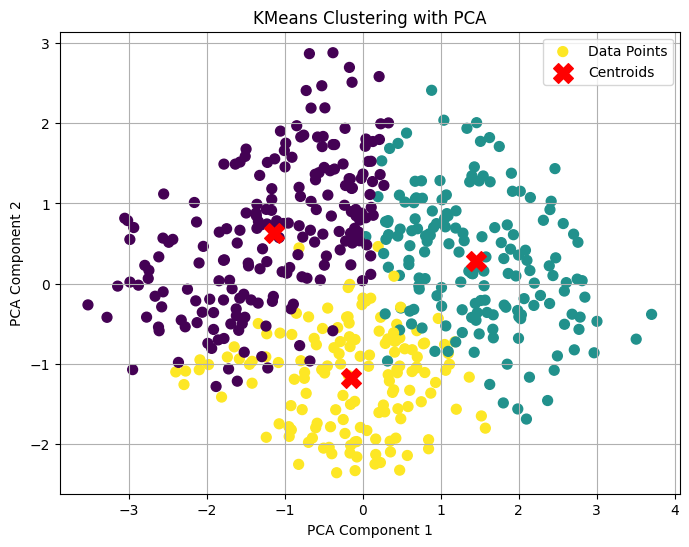

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv("bank.csv")

# Select numerical columns only for clustering
df_numeric = df.select_dtypes(include=[np.number])

# Normalize data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_numeric)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(data_scaled)

# Add cluster labels to original dataframe
df['Cluster'] = clusters

# Apply PCA to reduce dimensions for visualization
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)

# Plot clusters using PCA-reduced components
plt.figure(figsize=(8,6))
plt.scatter(data_pca[:, 0], data_pca[:, 1], c=clusters, cmap='viridis', s=50, label='Data Points')

# Plot cluster centers (after transforming with PCA)
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', s=200, marker='X', label='Centroids')

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("KMeans Clustering with PCA")
plt.legend()
plt.grid(True)
plt.show()


c. Apply Transformations to Triangle Image Using Numpy

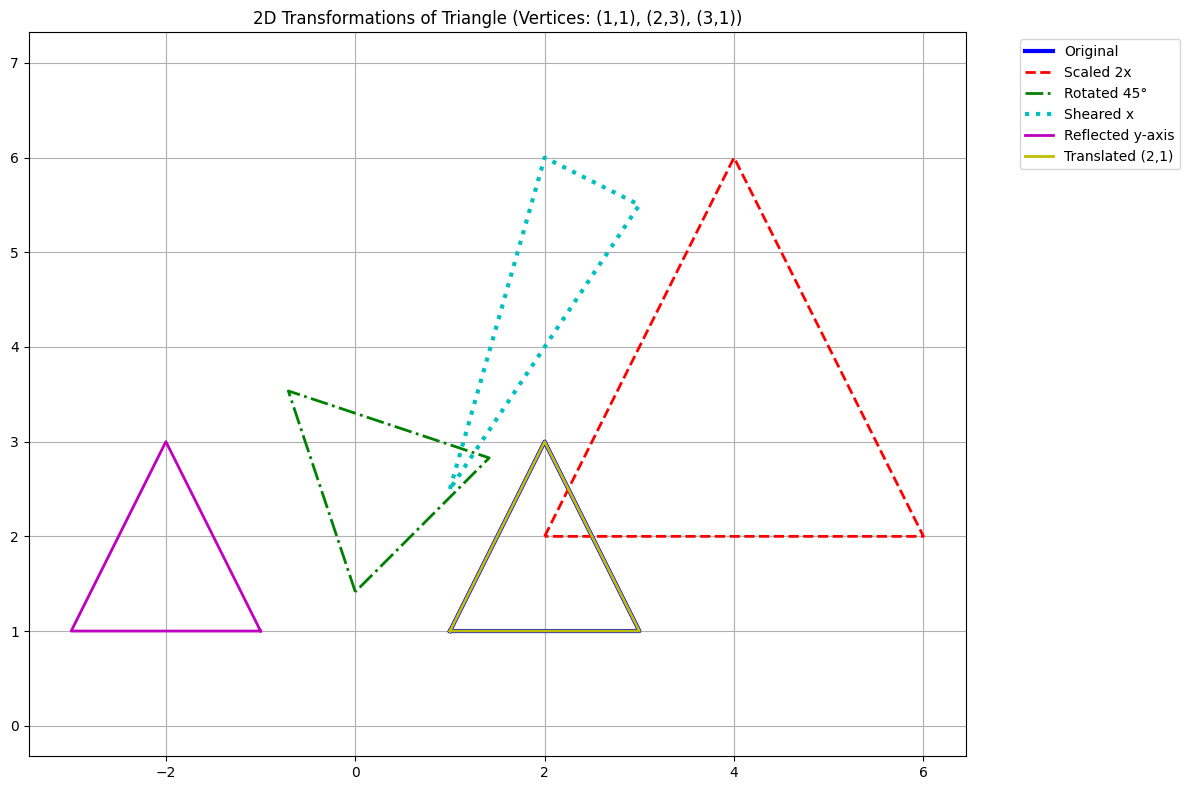

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define triangle vertices
triangle = np.array([[1, 1], [2, 3], [3, 1], [1, 1]])

# Create figure
plt.figure(figsize=(12, 8))

# Plot original triangle
plt.plot(triangle[:, 0], triangle[:, 1], 'b-', label='Original', linewidth=3)

# 1. Scaling (double the size)
scale_matrix = np.array([[2, 0],   # x-coordinate scaling
                         [0, 2]])  # y-coordinate scaling
scaled = np.dot(triangle[:, :2], scale_matrix)
plt.plot(scaled[:, 0], scaled[:, 1], 'r--', label='Scaled 2x', linewidth=2)

# 2. Rotation (45 degrees clockwise)
theta = np.radians(45)  # Convert degrees to radians
rot_matrix = np.array([[np.cos(theta), np.sin(theta)],
                       [-np.sin(theta), np.cos(theta)]])
rotated = np.dot(triangle[:, :2], rot_matrix)
plt.plot(rotated[:, 0], rotated[:, 1], 'g-.', label='Rotated 45°', linewidth=2)

# 3. Shearing (x-direction by factor 1.5)
shear_matrix = np.array([[1, 0],    # x-coordinate unchanged
                         [1.5, 1]]) # y-coordinate sheared based on x
sheared = np.dot(triangle[:, :2], shear_matrix.T)  # Transpose for correct multiplication
plt.plot(sheared[:, 0], sheared[:, 1], 'c:', label='Sheared x', linewidth=3)

# 4. Reflection (about y-axis)
reflect_matrix = np.array([[-1, 0],  # Flip x-coordinate
                           [0, 1]]) # y-coordinate unchanged
reflected = np.dot(triangle[:, :2], reflect_matrix)
plt.plot(reflected[:, 0], reflected[:, 1], 'm-', label='Reflected y-axis', linewidth=2)

# 5. Translation (move right by 2, up by 1 using homogeneous coordinates)
def translate_homogeneous(points, tx, ty):
    ones = np.ones((points.shape[0], 1))
    points_h = np.hstack([points[:, :2], ones])
    trans_matrix = np.array([[1, 0, 0],
                            [0, 1, 0],
                            [tx, ty, 1]])
    translated = np.dot(points_h, trans_matrix.T)
    return translated[:, :2]

translated = translate_homogeneous(triangle, 2, 1)
plt.plot(translated[:, 0], translated[:, 1], 'y-', label='Translated (2,1)', linewidth=2)

# Plot settings
plt.axis('equal')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('2D Transformations of Triangle (Vertices: (1,1), (2,3), (3,1))')
plt.tight_layout()
plt.show()

We have applied a series of 2D transformations to a triangle defined by three points. Each transformation was implemented using appropriate transformation matrices:

Scaling: A scaling matrix doubled the size of the triangle.

Rotation: The triangle was rotated 45° clockwise using a rotation matrix.

Shearing: A shear matrix altered the triangle shape along the x-axis.

Reflection: A reflection matrix was used to flip the triangle about the y-axis.

Translation: Using homogeneous coordinates, translated the triangle by (2, 1).
All transformations were visualized on a single plot for comparison.

Q4.
b. Compute the Eigenvalues and Eigenvectors of Matrix A

In [ ]:
import numpy as np

A = np.array([[4, 1],
              [2, 3]])

# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(A)

print("Eigenvalues:")
print(eigenvalues)

print("\nEigenvectors:")
print(eigenvectors)


Eigenvalues:
[5. 2.]

Eigenvectors:
[[ 0.70710678 -0.4472136 ]
 [ 0.70710678  0.89442719]]


c. Cosine Similarity and Pearson Correlation

In [ ]:
import numpy as np
from scipy.spatial.distance import cosine
from scipy.stats import pearsonr

u = np.array([1, 0, 1, 0])
v = np.array([0, 1, 0, 1])

# Cosine Similarity
cos_sim = 1 - cosine(u, v)

# Pearson Correlation
pearson_corr, _ = pearsonr(u, v)

print("Cosine Similarity:", cos_sim)
print("Pearson Correlation:", pearson_corr)


Cosine Similarity: 0.0
Pearson Correlation: -1.0


Q8. c) ELM on MNIST Handwritten Digit Classification using NumPy

The following NumPy-based code implements an ELM architecture to classify handwritten digits from the MNIST dataset. It uses a single hidden layer with randomly initialized weights, a sigmoid activation function, and a closed-form solution for output weights via Moore-Penrose pseudo-inverse.

In [23]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load MNIST dataset
mnist = fetch_openml('mnist_784', version=1)
X = np.array(mnist.data) / 255.0  # Normalize
y = np.array(mnist.target, dtype=int)

# One-hot encode the labels
encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y.reshape(-1, 1))

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, train_size=5000, test_size=1000, random_state=42)

# Define ELM model
class ELM:
    def __init__(self, input_size, hidden_size, output_size):
        self.input_weights = np.random.randn(input_size, hidden_size)
        self.bias = np.random.randn(hidden_size)
        self.output_weights = None

    def activation(self, x):
        return 1 / (1 + np.exp(-x))  # Sigmoid

    def train(self, X, Y):
        H = self.activation(X @ self.input_weights + self.bias)
        H_pinv = np.linalg.pinv(H)
        self.output_weights = H_pinv @ Y
        return H @ self.output_weights  # Return training predictions

    def predict(self, X):
        H = self.activation(X @ self.input_weights + self.bias)
        Y_pred = H @ self.output_weights
        return np.argmax(Y_pred, axis=1)

# Train ELM and get training predictions
elm = ELM(input_size=784, hidden_size=1000, output_size=10)
train_pred = elm.train(X_train, y_train)

# Calculate training accuracy
train_pred_labels = np.argmax(train_pred, axis=1)
train_true_labels = np.argmax(y_train, axis=1)
train_acc = accuracy_score(train_true_labels, train_pred_labels)

# Test predictions
test_pred_labels = elm.predict(X_test)
test_true_labels = np.argmax(y_test, axis=1)
test_acc = accuracy_score(test_true_labels, test_pred_labels)

# Print results
print(f"ELM Training Accuracy on MNIST subset: {train_acc:.4f}")
print(f"ELM Test Accuracy on MNIST subset: {test_acc:.4f}")

ELM Training Accuracy on MNIST subset: 0.9764
ELM Test Accuracy on MNIST subset: 0.9090
